In [1]:
import cv2
import time
import os
import random
import insightface
import numpy as np
from tqdm import tqdm
from pathlib import Path
from contextlib import redirect_stdout
from IPython.display import display
from PIL import Image

# ユーザ設定 --------------------------
PROVIDER = "GPU"                # "CPU" or "CUDA" (onnxruntime-gpu入れてるなら"CUDA")
DET_MODEL = "buffalo_s"           # 使用するモデル名
DET_SIZE = (512, 512)           # 推論サイズ (小さくすると速い ただし遠距離の小さい顔に弱くなる)
# ------------------------------------

def init_detector(model = "buffalo_s", provider="CPU", det_size=(640, 640)):

    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull):
            app = insightface.app.FaceAnalysis(
                name = model,
                providers=["CUDAExecutionProvider" if provider == "CUDA" else "CPUExecutionProvider"]
            )
            app.prepare(
                ctx_id = 0 if provider == "CUDA" else -1, 
                det_thresh=0.6,
                det_size = det_size
            )

    return app

def draw_face_position(img_bgr, faces, *, use_kps_refine=True, use_kps_only=False, pad_ratio=0.06, show_landmarks=True, show_score=True, show_details=False, bbox_color=(0,255,0), thickness=2) -> np.ndarray:
    """
    検出された顔のバウンディングボックスをimg_bgrに描画して返す
    faces: list[Face]

    追加オプション:
      use_kps_refine: ランドマーク(kps)があればそれを使ってbboxを顔領域に補正する
      use_kps_only: ランドマークのみで bbox を計算する（検出器のbboxを無視）
      pad_ratio: ランドマーク/box に対するパディング比率（小さくするとタイトになる）
      show_landmarks: ランドマークを赤点で描画する
      show_score: 検出スコアを表示する
      show_details: bbox座標やサイズなどの詳細を複数行表示する
      bbox_color, thickness: 描画色・線幅

    実装メモ:
      - face.bbox が順序 (x1,y1,x2,y2) でない可能性があるため、座標を正規化してから使用します
      - ランドマークがある場合はランドマークの範囲を利用して bbox をタイトにし、pad_ratio に基づくパディングを追加します
    """
    out = img_bgr.copy()
    h, w = out.shape[:2]

    for face in faces:
        # 元の検出 bbox を安全に整形
        box = face.bbox.astype(int)
        bx1 = max(0, min(int(box[0]), int(box[2])))
        by1 = max(0, min(int(box[1]), int(box[3])))
        bx2 = min(w - 1, max(int(box[0]), int(box[2])))
        by2 = min(h - 1, max(int(box[1]), int(box[3])))

        x1, y1, x2, y2 = bx1, by1, bx2, by2

        kps = None
        if use_kps_refine and hasattr(face, 'kps') and face.kps is not None:
            try:
                kps = np.asarray(face.kps)
                if kps.size > 0:
                    kx1 = int(max(0, kps[:, 0].min()))
                    ky1 = int(max(0, kps[:, 1].min()))
                    kx2 = int(min(w - 1, kps[:, 0].max()))
                    ky2 = int(min(h - 1, kps[:, 1].max()))

                    if use_kps_only:
                        base_w = max(1, kx2 - kx1)
                        base_h = max(1, ky2 - ky1)
                        pad = int(pad_ratio * max(base_w, base_h))
                        x1 = max(0, kx1 - pad)
                        y1 = max(0, ky1 - pad)
                        x2 = min(w - 1, kx2 + pad)
                        y2 = min(h - 1, ky2 + pad)
                    else:
                        # 検出 bbox と kps の両方を考慮してタイトにする（より保守的な方法）
                        combined_x1 = min(bx1, kx1)
                        combined_y1 = min(by1, ky1)
                        combined_x2 = max(bx2, kx2)
                        combined_y2 = max(by2, ky2)
                        base_w = max(1, combined_x2 - combined_x1)
                        base_h = max(1, combined_y2 - combined_y1)
                        pad = int(pad_ratio * max(base_w, base_h))
                        x1 = max(0, combined_x1 - pad)
                        y1 = max(0, combined_y1 - pad)
                        x2 = min(w - 1, combined_x2 + pad)
                        y2 = min(h - 1, combined_y2 + pad)
            except Exception:
                kps = None

        # 描画
        cv2.rectangle(out, (x1, y1), (x2, y2), bbox_color, thickness)

        # ランドマーク描画 (赤)
        if show_landmarks and kps is not None:
            for (lx, ly) in kps.astype(int):
                lx = int(np.clip(lx, 0, w - 1))
                ly = int(np.clip(ly, 0, h - 1))
                cv2.circle(out, (lx, ly), 2, (0, 0, 255), -1)

        # 表示テキストを組み立てる
        score = getattr(face, 'det_score', None)
        lines = []
        if show_score and score is not None:
            lines.append(f"score: {float(score):.2f}")
        if show_details:
            lines.append(f"bbox: {x1},{y1},{x2},{y2}")
            lines.append(f"size: {x2-x1}x{y2-y1}")
            if hasattr(face, 'kps') and face.kps is not None:
                try:
                    kp_shape = np.asarray(face.kps).shape
                    lines.append(f"kps: {kp_shape}")
                except Exception:
                    pass

        # テキストを bbox の上に複数行で描画（上に描く）
        for i, text in enumerate(lines):
            y_text = max(y1 - 5 - i * 15, 0)
            cv2.putText(out, text, (x1, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.5, bbox_color, 1, cv2.LINE_AA)

    return out

def extract_frames(video_path, frame_num=3, margin=0.1):
    """
    動画ファイルからフレームを抽出する
    
    Args:
        video_path: 動画ファイルのパス
        frame_num: 抽出するフレーム数（デフォルト: 3）
        margin: 前後の除外比率（デフォルト: 0.1 = 前後10%除外）
    
    Returns:
        抽出されたフレームのリスト [ndarray, ...]
    """
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"動画が開けません: {video_path}")
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # 前後margin分を除外した範囲を計算
    start_frame = int(total_frames * margin)
    end_frame = int(total_frames * (1 - margin))
    
    # 等間隔のフレーム位置を計算
    frame_indices = np.linspace(start_frame, end_frame, frame_num, dtype=int)
    
    frames = []
    for frame_idx in tqdm(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames


# 1. 顔検出器初期化
app = init_detector(model=DET_MODEL, provider=PROVIDER, det_size=DET_SIZE)


c:\Users\kenta\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kenta\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 画像

In [ ]:
# サンプル画像ランダム選択
image_dir = Path("../sample_face/")
sample_img = random.choice(list(image_dir.glob("**/*.*")))

# 2. 画像読み込み (BGR)
img_bgr = cv2.imread(str(sample_img))
if img_bgr is None:
    raise FileNotFoundError(f"画像が読めません: {sample_img}")

# 3. 顔検出
start_time = time.time()
faces = app.get(img_bgr)
print(f"検出時間: {time.time() - start_time:.5f} 秒")

# 5. 可視化して保存
vis = draw_face_position(img_bgr, faces)
display(Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)).resize((int(256 * vis.shape[1] / vis.shape[0]), 256)))

## 動画

In [ ]:
# サンプル画像ランダム選択
video_dir = Path(".")
sample_video = random.choice(list(video_dir.glob("**/*.mp4")))

for frame in extract_frames(sample_video, frame_num=3, margin=0.1):
    # 3. 顔検出
    faces = app.get(frame)

    # 5. 可視化
    vis = draw_face_position(frame, faces)
    display(Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)).resize((int(199 * vis.shape[1] / vis.shape[0]), 199)))


## 分類

  0%|          | 0/30 [00:00<?, ?it/s]C:\Users\kenta\AppData\Roaming\Python\Python312\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 30/30 [00:05<00:00,  5.26it/s]


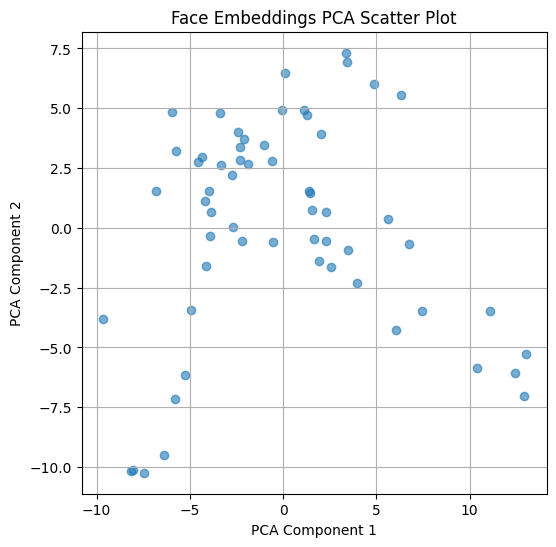

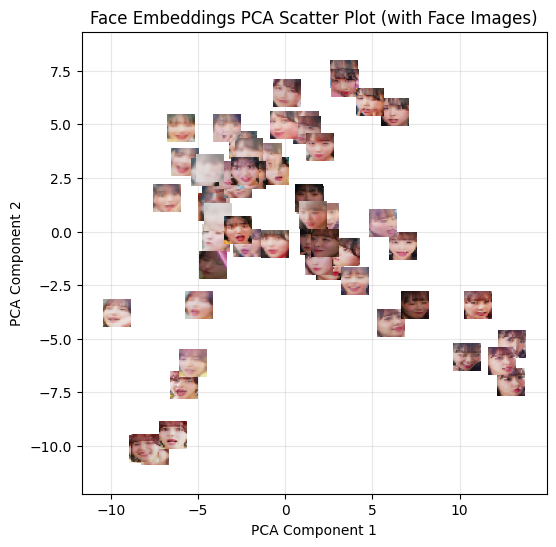

In [5]:
# サンプル画像ランダム選択
video_dir = Path(".")
sample_video = random.choice(list(video_dir.glob("**/*.mp4")))
sample_video = Path("./20240401_【MV】FRUITS ZIPPER「NEW KAWAII」_7Am9TCA3WrA.mp4")

all_face_imgs = []
all_face_embeddings = []

from tqdm import tqdm
for frame in tqdm(extract_frames(sample_video, frame_num=30, margin=0.1)):
    # 3. 顔検出
    faces = app.get(frame)
    all_face_imgs += [frame[int(face.bbox[1]):int(face.bbox[3]), int(face.bbox[0]):int(face.bbox[2])] for face in faces]
    all_face_embeddings += [face.embedding for face in faces if hasattr(face, 'embedding')]


# PCAで次元削減して散布図表示
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_face_embeddings)
plt.figure(figsize=(6,6))
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.6)
plt.title("Face Embeddings PCA Scatter Plot")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

# 画像を使って散布図を表
fig, ax = plt.subplots(figsize=(6, 6))
for idx, (x, y) in enumerate(reduced_embeddings):
    if idx < len(all_face_imgs):
        face_img = all_face_imgs[idx]
        face_img_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
        # 顔画像をリサイズして小さくする
        face_img_small = cv2.resize(face_img_rgb, (20, 20))
        imagebox = OffsetImage(face_img_small, zoom=1.0)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, bboxprops=dict(boxstyle="round,pad=0.3"))
        ax.add_artist(ab)

ax.set_xlim(reduced_embeddings[:, 0].min() - 2, reduced_embeddings[:, 0].max() + 2)
ax.set_ylim(reduced_embeddings[:, 1].min() - 2, reduced_embeddings[:, 1].max() + 2)
ax.set_title("Face Embeddings PCA Scatter Plot (with Face Images)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.grid(True, alpha=0.3)
plt.show()

## 計測

In [ ]:
from tqdm import tqdm

# ユーザ設定 --------------------------
PROVIDER = "GPU"                # "CPU" or "CUDA" (onnxruntime-gpu入れてるなら"CUDA")
DET_MODEL = "buffalo_s"           # 使用するモデル名
DET_SIZE = (512, 512)           # 推論サイズ (小さくすると速い ただし遠距離の小さい顔に弱くなる)
# ------------------------------------
app = init_detector(model=DET_MODEL, provider=PROVIDER, det_size=DET_SIZE)

# 平均時間計測
n_iters = 30
total_time = 0.0

image_dir = Path("../sample_face/")
imgs = [cv2.imread(str(p)) for p in random.choices(list(image_dir.glob("**/*.*")), k=n_iters)]

for _ in tqdm(range(n_iters)):
    start_time = time.time()
    faces = app.get(img_bgr)
    elapsed = time.time() - start_time
    total_time += elapsed

print(f"平均検出時間 ({n_iters}回): {total_time / n_iters:.5f} 秒")